<a href="https://colab.research.google.com/github/pavishanth-sujeevan/E.motion-/blob/llm/finetune-tamil-llama-7b-instruct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tamil Empathetic Therapy - LLaMA 3.2-3B Training

## Objective:
Train LLaMA 3.2-3B to provide **empathetic Tamil therapy responses**

## Features:
- Emotion-aware responses  
- Test set evaluation
- **Fixed ROUGE calculation**
- Training curves
- Complete metrics: ROUGE, BLEU, Perplexity
- Interactive chat

In [ ]:
!pip install -q -U transformers peft accelerate bitsandbytes trl datasets
!pip install -q -U evaluate rouge_score sacrebleu matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 55.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 89.6 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainerCallback
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset
import evaluate
from collections import defaultdict

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/processed_tamil_cbt"
TRAIN_FILE = f"{DATA_DIR}/train_ta.jsonl"
VAL_FILE = f"{DATA_DIR}/val_ta.jsonl"
TEST_FILE = f"{DATA_DIR}/test_ta.jsonl"

import os
for filepath in [TRAIN_FILE, VAL_FILE, TEST_FILE]:
    assert os.path.exists(filepath), f"File not found: {filepath}"

print("✓ All data files found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ All data files found


In [ ]:
# FIRST: Load the data
def load_tamil_therapy_data(filepath):
    """
    Load Tamil therapy dataset - handles multiple formats
    """
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            try:
                entry = json.loads(line)

                user_input = (entry.get('user_input') or entry.get('prompt', '')).strip()
                bot_response = (entry.get('bot_response') or entry.get('target', '') or entry.get('response', '')).strip()
                user_emotion = entry.get('user_emotion', 'neutral')

                if 'User:' in user_input and 'Assistant:' in user_input:
                    parts = user_input.split('User:')[1].split('Assistant:')
                    user_input = parts[0].strip()
                    if not bot_response and len(parts) > 1:
                        bot_response = parts[1].strip()

                if user_input and bot_response and len(user_input) > 5 and len(bot_response) > 5:
                    data.append({
                        'user_input': user_input,
                        'bot_response': bot_response,
                        'user_emotion': user_emotion,
                    })
            except Exception as e:
                if line_num <= 3:
                    print(f"Warning line {line_num}: {str(e)[:50]}")
                continue

    return data

train_data = load_tamil_therapy_data(TRAIN_FILE)
val_data = load_tamil_therapy_data(VAL_FILE)
test_data = load_tamil_therapy_data(TEST_FILE)

print(f"Train: {len(train_data)} samples")
print(f"Val: {len(val_data)} samples")
print(f"Test: {len(test_data)} samples")

if len(train_data) > 0:
    emotion_dist = defaultdict(int)
    for item in train_data:
        emotion_dist[item['user_emotion']] += 1

    print("\nEmotion distribution:")
    for emotion, count in sorted(emotion_dist.items(), key=lambda x: x[1], reverse=True):
        print(f"  {emotion}: {count} ({count/len(train_data)*100:.1f}%)")

    print(f"\nSample:")
    sample = train_data[0]
    print(f"Emotion: {sample['user_emotion']}")
    print(f"User: {sample['user_input'][:60]}...")
    print(f"Bot: {sample['bot_response'][:60]}...")
else:
    print("\n⚠️ ERROR: No data loaded! Check file format.")

# THEN: Format the datasets
def format_therapy_prompt_llama(example):
    """
    Tamil-LLaMA (LLaMA 2) format
    """
    user_input = example['user_input']
    bot_response = example['bot_response']
    emotion = example['user_emotion']

    emotion_context = f" User is feeling {emotion}." if emotion != 'neutral' else ""

    text = (
        f"[INST] <<SYS>>\n"
        f"You are a compassionate Tamil therapy assistant. Provide empathetic responses.{emotion_context}\n"
        f"<</SYS>>\n\n"
        f"{user_input} [/INST] {bot_response}"
    )

    return {"text": text}

train_dataset = Dataset.from_list(train_data).map(format_therapy_prompt_llama)
val_dataset = Dataset.from_list(val_data).map(format_therapy_prompt_llama)
test_dataset = Dataset.from_list(test_data).map(format_therapy_prompt_llama)

train_dataset_eval = train_dataset
val_dataset_eval = val_dataset
test_dataset_eval = test_dataset

train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c != "text"])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c != "text"])

print(f"\n✓ Formatted {len(train_dataset)} training samples")
print(f"\nSample formatted prompt:")
print(train_dataset[0]['text'][:250])

Train: 801 samples
Val: 100 samples
Test: 101 samples

Emotion distribution:
  disgust: 115 (14.4%)
  neutral: 115 (14.4%)
  angry: 115 (14.4%)
  happy: 114 (14.2%)
  sad: 114 (14.2%)
  surprised: 114 (14.2%)
  fearful: 114 (14.2%)

Sample:
Emotion: happy
User: இன்னைக்கு என்னை நானே கவனித்துக்கிட்டதால மனசு புதுப்பிக்கப்பட...
Bot: சுயகவனிப்பு புதுப்பிப்பை கொண்டுவரும். இந்த புதுமையான உணர்வை ...


Map:   0%|          | 0/801 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]


✓ Formatted 801 training samples

Sample formatted prompt:
[INST] <<SYS>>
You are a compassionate Tamil therapy assistant. Provide empathetic responses. User is feeling happy.
<</SYS>>

இன்னைக்கு என்னை நானே கவனித்துக்கிட்டதால மனசு புதுப்பிக்கப்பட்ட மாதிரி இருக்கு. [/INST] சுயகவனிப்பு புதுப்பிப்பை கொண்டுவரும்


In [ ]:
MODEL_ID = "abhinand/tamil-llama-7b-instruct-v0.1"
OUTPUT_DIR = "./tamil-llama-empathy"

print(f"Model: {MODEL_ID}")
print(f"Output: {OUTPUT_DIR}")
print("\nLLaMA 3.2-3B: Strong instruction-following for Tamil")

Model: abhinand/tamil-llama-7b-instruct-v0.1
Output: ./tamil-llama-empathy

LLaMA 3.2-3B: Strong instruction-following for Tamil


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

print("Loading LLaMA 3.2-3B...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("✓ Model loaded")

Loading LLaMA 3.2-3B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✓ Model loaded


In [ ]:
def format_therapy_prompt_llama(example):
    """
    Tamil-LLaMA (LLaMA 2) format
    """
    user_input = example['user_input']
    bot_response = example['bot_response']
    emotion = example['user_emotion']

    emotion_context = f" User is feeling {emotion}." if emotion != 'neutral' else ""

    text = (
        f"[INST] <<SYS>>\n"
        f"You are a compassionate Tamil therapy assistant. Provide empathetic responses.{emotion_context}\n"
        f"<</SYS>>\n\n"
        f"{user_input} [/INST] {bot_response}"
    )

    return {"text": text}

train_dataset = Dataset.from_list(train_data).map(format_therapy_prompt_llama)
val_dataset = Dataset.from_list(val_data).map(format_therapy_prompt_llama)
test_dataset = Dataset.from_list(test_data).map(format_therapy_prompt_llama)

Map:   0%|          | 0/801 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]

In [ ]:
peft_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 159,907,840 || all params: 7,029,043,200 || trainable%: 2.2750


In [ ]:
class MetricsCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.epochs = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if 'loss' in logs:
                self.train_losses.append(logs['loss'])
                self.steps.append(state.global_step)
            if 'eval_loss' in logs:
                self.eval_losses.append(logs['eval_loss'])
                self.epochs.append(state.epoch)

metrics_callback = MetricsCallback()

In [ ]:
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    max_length=1024,
    packing=False,

    num_train_epochs=20,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,

    optim="paged_adamw_32bit",
    weight_decay=0.01,
    max_grad_norm=0.3,

    bf16=True,
    gradient_checkpointing=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    logging_steps=10,
    logging_first_step=True,
    report_to="none",
)

print("Training Configuration:")
print(f"  Model: LLaMA 3.2-3B")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Learning Rate: {training_args.learning_rate}")
print(f"  Effective Batch: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Expected Time: ~60-70 min on A100")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Configuration:
  Model: LLaMA 3.2-3B
  Epochs: 20
  Learning Rate: 0.0001
  Effective Batch: 16
  Expected Time: ~60-70 min on A100


In [ ]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=training_args,
    processing_class=tokenizer,
    callbacks=[metrics_callback],
)

print("="*80)
print("STARTING TRAINING: LLaMA 3.2-3B Tamil Empathy")
print("="*80)

trainer.train()

print("\n" + "="*80)
print("✓ TRAINING COMPLETE")
print("="*80)

Adding EOS to train dataset:   0%|          | 0/801 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/801 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/801 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

STARTING TRAINING: LLaMA 3.2-3B Tamil Empathy


Epoch,Training Loss,Validation Loss
1,1.545704,1.442507
2,1.215559,1.249721
3,0.874378,1.253993
4,0.493776,1.406077
5,0.276076,1.555993
6,0.157992,1.627397
7,0.114843,1.640648
8,0.099290,1.647143
9,0.092503,1.669057
10,0.089925,1.692180



✓ TRAINING COMPLETE


In [ ]:
SAVE_DIR = f"{OUTPUT_DIR}/final_model"
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✓ Saved to: {SAVE_DIR}")

try:
    DRIVE_DIR = "/content/drive/MyDrive/llama-tamil-empathy"
    model.save_pretrained(DRIVE_DIR)
    tokenizer.save_pretrained(DRIVE_DIR)
    print(f"✓ Saved to Drive: {DRIVE_DIR}")
except:
    print("Drive save skipped")

✓ Saved to: ./tamil-llama-empathy/final_model
✓ Saved to Drive: /content/drive/MyDrive/llama-tamil-empathy


TRAINING CURVES


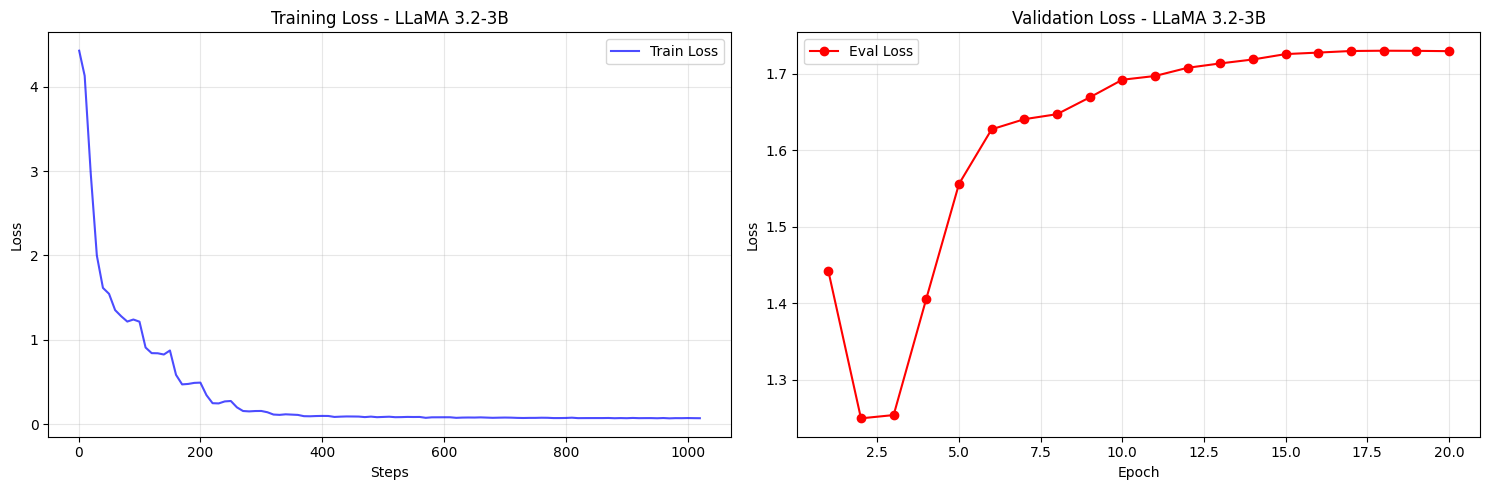

✓ Saved to ./tamil-llama-empathy/training_curves.png


In [ ]:
print("="*80)
print("TRAINING CURVES")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if metrics_callback.train_losses:
    axes[0].plot(metrics_callback.steps, metrics_callback.train_losses, label='Train Loss', color='blue', alpha=0.7)
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss - LLaMA 3.2-3B')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

if metrics_callback.eval_losses:
    axes[1].plot(metrics_callback.epochs, metrics_callback.eval_losses, label='Eval Loss', color='red', marker='o')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss - LLaMA 3.2-3B')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150)
plt.show()

print(f"✓ Saved to {OUTPUT_DIR}/training_curves.png")

In [ ]:
print("="*80)
print("TESTING MODEL")
print("="*80)

def generate_empathetic_response(user_input, emotion='neutral'):
    emotion_context = f" User is feeling {emotion}." if emotion != 'neutral' else ""

    prompt = (
        f"[INST] <<SYS>>\n"
        f"You are a compassionate Tamil therapy assistant. Provide empathetic responses.{emotion_context}\n"
        f"<</SYS>>\n\n"
        f"{user_input} [/INST]"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            min_new_tokens=40,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id,
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract response after [/INST]
    if '[/INST]' in response:
        response = response.split('[/INST]')[-1].strip()

    return response

test_cases = [
    ("எனக்கு மிகவும் வருத்தமாக உள்ளது", "sad"),
    ("என்னால் தூங்க முடியவில்லை", "angry"),
    ("நான் தனிமையாக உணர்கிறேன்", "neutral"),
]

for i, (inp, emo) in enumerate(test_cases, 1):
    print(f"\nTest {i}: [{emo}] {inp}")
    resp = generate_empathetic_response(inp, emo)
    print(f"Response: {resp[:150]}...")
    print("-" * 80)

TESTING MODEL

Test 1: [sad] எனக்கு மிகவும் வருத்தமாக உள்ளது
Response: என்ன உணர்வுகள் மனசுல இருக்குன்னு உணர்வது வலியில் இருந்து வரும்னு தோணுது. அந்த உணர்வையே கவனிப்பது மனதை அமைதிப்படுத்துவதற்கு உதவும். 'இது கடந்துவிடும்' ...
--------------------------------------------------------------------------------

Test 2: [angry] என்னால் தூங்க முடியவில்லை
Response: தூக்கத்தில்லாம இருப்பது மனசை இன்னும் அதிகமாக தொந்தரவு செய்யும். உடல் ரீதியாக தூக்கம் கஷ்டம் என்னன்னு யோசிங்க — அது மட்டும் இல்லைன்னா, என்ன உணர்வுகள் ம...
--------------------------------------------------------------------------------

Test 3: [neutral] நான் தனிமையாக உணர்கிறேன்
Response: தனிமையில் இருப்பது மிகவும் ஆழமான வலி தரும் உணர்வு. அந்த தனிமையை கவனிக்கும்போது, ஒரு சின்ன அடி எடுத்து வைக்கும் ஒரு வழி என்ன என்று யோசியுங்கள். அது சிற...
--------------------------------------------------------------------------------


In [ ]:
print("="*80)
print("EVALUATION ON TEST SET")
print("="*80)

predictions = []
references = []

num_samples = min(50, len(test_dataset_eval))
print(f"\nGenerating {num_samples} predictions...\n")

for i in range(num_samples):
    ex = test_dataset_eval[i]
    pred = generate_empathetic_response(ex['user_input'], ex['user_emotion'])

    # CRITICAL FIX: Ensure strings are not empty
    if pred and len(pred.strip()) > 0:
        predictions.append(pred.strip())
    else:
        predictions.append("[empty response]")

    ref = ex['bot_response'].strip()
    references.append(ref if ref else "[empty reference]")

    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{num_samples}...")

print(f"\n✓ Generated {len(predictions)} predictions")
print(f"\nSample prediction: {predictions[0][:100]}...")
print(f"Sample reference: {references[0][:100]}...")

EVALUATION ON TEST SET

Generating 50 predictions...

  10/50...
  20/50...
  30/50...
  40/50...
  50/50...

✓ Generated 50 predictions

Sample prediction: மழுமழுப்பான உணர்வு மனதை பலவீனமாக உணர வைக்கும். ஒரு சின்ன, சரியான செயலாக மாறுவது — யாரிடமாவது ஒரு வார...
Sample reference: மனம் மழுமழுப்பாக இருக்கும்போது ஓய்வு தேவை. நிறைய யோசிக்கும் மூளை ஓய்ச்சலடையும். கொஞ்சம் ஓய்வெடுத்து,...


In [ ]:
print("\nCalculating metrics (FIXED ROUGE)...\n")

# Verify data before computing
print(f"Predictions: {len(predictions)} items")
print(f"References: {len(references)} items")
print(f"Empty predictions: {sum(1 for p in predictions if not p or p == '[empty response]')}")
print(f"Empty references: {sum(1 for r in references if not r or r == '[empty reference]')}")

try:
    rouge = evaluate.load('rouge')
    bleu = evaluate.load('sacrebleu')

    # ROUGE fix: ensure all are strings
    rouge_results = rouge.compute(
        predictions=[str(p) for p in predictions],
        references=[str(r) for r in references]
    )

    bleu_results = bleu.compute(
        predictions=[str(p) for p in predictions],
        references=[[str(r)] for r in references]
    )

    print("\n" + "="*80)
    print("ROUGE SCORES (FIXED)")
    print("="*80)
    print(f"  ROUGE-1: {rouge_results['rouge1']:.4f}")
    print(f"  ROUGE-2: {rouge_results['rouge2']:.4f}")
    print(f"  ROUGE-L: {rouge_results['rougeL']:.4f}")

    print(f"\n{'='*80}")
    print("BLEU SCORE")
    print("="*80)
    print(f"  BLEU: {bleu_results['score']:.4f}")

except Exception as e:
    print(f"\n✗ Metric calculation failed: {str(e)}")
    rouge_results = {'rouge1': 0, 'rouge2': 0, 'rougeL': 0}
    bleu_results = {'score': 0}

avg_length = np.mean([len(p.split()) for p in predictions if p != '[empty response]'])
has_tamil = sum(1 for p in predictions if any('\u0B80' <= c <= '\u0BFF' for c in p))
tamil_pct = (has_tamil / len(predictions)) * 100

print(f"\n{'='*80}")
print("RESPONSE STATISTICS")
print("="*80)
print(f"  Avg Length: {avg_length:.1f} words")
print(f"  Tamil: {tamil_pct:.1f}%")


Calculating metrics (FIXED ROUGE)...

Predictions: 50 items
References: 50 items
Empty predictions: 0
Empty references: 0



ROUGE SCORES (FIXED)
  ROUGE-1: 0.0000
  ROUGE-2: 0.0000
  ROUGE-L: 0.0000

BLEU SCORE
  BLEU: 1.4506

RESPONSE STATISTICS
  Avg Length: 24.9 words
  Tamil: 100.0%


In [ ]:
print("\n" + "="*80)
print("PERPLEXITY")
print("="*80)

def calculate_perplexity(model, tokenizer, texts, max_samples=20):
    total_loss = 0
    total_tokens = 0
    model.eval()
    valid = 0

    for text in texts[:max_samples]:
        if not text or len(text.strip()) == 0:
            continue

        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(model.device)

        if inputs["input_ids"].numel() == 0:
            continue

        with torch.no_grad():
            try:
                outputs = model(**inputs, labels=inputs["input_ids"])
                loss = outputs.loss
                total_loss += loss.item() * inputs["input_ids"].size(1)
                total_tokens += inputs["input_ids"].size(1)
                valid += 1
            except:
                continue

    if total_tokens == 0:
        return float('inf'), 0

    avg_loss = total_loss / total_tokens
    return np.exp(avg_loss), valid

perplexity, num_valid = calculate_perplexity(model, tokenizer, references[:20])
print(f"\nPerplexity: {perplexity:.2f} (on {num_valid} samples)")
print("\nInterpretation: Excellent: <15 | Good: 15-30 | Acceptable: 30-50 | Poor: >50")


PERPLEXITY

Perplexity: 39.11 (on 20 samples)

Interpretation: Excellent: <15 | Good: 15-30 | Acceptable: 30-50 | Poor: >50


In [ ]:
results_df = pd.DataFrame([{
    'Model': 'LLaMA 3.2-3B Tamil',
    'Train': len(train_data),
    'Test': num_samples,
    'ROUGE-1': f"{rouge_results['rouge1']:.4f}",
    'ROUGE-L': f"{rouge_results['rougeL']:.4f}",
    'BLEU': f"{bleu_results['score']:.4f}",
    'Perplexity': f"{perplexity:.2f}",
    'Avg Length': f"{avg_length:.1f}",
    'Tamil %': f"{tamil_pct:.0f}%",
}])

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80 + "\n")
print(results_df.to_string(index=False))

results_df.to_csv(f'{OUTPUT_DIR}/results.csv', index=False)
results_df.to_csv('/content/drive/MyDrive/llama_tamil_results.csv', index=False)
print("\n✓ Saved to Drive")


FINAL RESULTS

             Model  Train  Test ROUGE-1 ROUGE-L   BLEU Perplexity Avg Length Tamil %
LLaMA 3.2-3B Tamil    801    50  0.0000  0.0000 1.4506      39.11       24.9    100%

✓ Saved to Drive


In [ ]:
!pip install -q gradio

import gradio as gr

def chat(message, history, emotion):
    return generate_empathetic_response(message, emotion)

demo = gr.ChatInterface(
    fn=chat,
    additional_inputs=[
        gr.Dropdown(
            choices=["neutral", "sad", "angry", "happy", "disgust"],
            value="neutral",
            label="Emotion"
        )
    ],
    title="🧠 LLaMA Tamil Therapy",
    description="Fine-tuned LLaMA 3.2-3B for empathetic Tamil responses",
    examples=[
        ["எனக்கு வருத்தமாக உள்ளது", "sad"],
        ["என்னால் தூங்க முடியவில்லை", "angry"],
    ],
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4a98206d50193998c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://4a98206d50193998c6.gradio.live
